In [6]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 윈도우 맑은 고딕 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [184]:
base_path = r"C:\kdt_0900_pjh\data_analysis\resource\dataset"
file_name = r"hr_employee_attrition.csv"

file_path = os.path.join(base_path, file_name)

df = pd.read_csv(file_path)

## 1. 야근(OverTime)을 하는 직원과 하지 않는 직원의 이직(Attrition) 비율은 얼마나 차이가 나는지 그래프로 나타내고 분석 결과를 서술하세요.
- 집계 및 시각화: OverTime별 Attrition 비율(백분율, %)을 계산하고, 수치 차이가 대비되는 누적/그룹 그래프를 생성하세요.

Attrition         No        Yes
OverTime                       
No         89.563567  10.436433
Yes        69.471154  30.528846



<Figure size 1000x500 with 0 Axes>

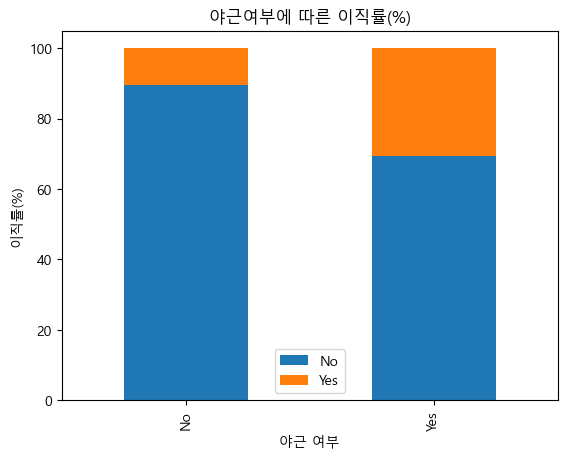

검증
----------------------------------------------------------
야근을 하지 않는 인원(10.4%) 대비 야근을 하는 인원(30.5%)의
 이직률이 20.1% 더 높은 것을 확인할 수 있다
가설은 참이다!
----------------------------------------------------------


In [175]:
overtime_attrition = (pd.crosstab(df["OverTime"], df["Attrition"], normalize="index")*100)
print(overtime_attrition, end="\n\n")

plt.figure(figsize=(10, 5))
overtime_attrition_df.plot(kind="bar", stacked=True)
plt.title("야근여부에 따른 이직률(%)")
plt.xlabel("야근 여부")
plt.ylabel("이직률(%)")
plt.legend()
plt.show()

print("검증")
print("----------------------------------------------------------")
print("야근을 하지 않는 인원(10.4%) 대비 야근을 하는 인원(30.5%)의\n 이직률이 20.1% 더 높은 것을 확인할 수 있다\n가설은 참이다!")
print("----------------------------------------------------------")

## 2. 이직한 직원(Yes)과 잔류한 직원(No)의 월소득(MonthlyIncome) 평균 및 분포(Boxplot)에는 어떤 차이가 있는지 결과를 분석하고 그래프로 나타내고 서술하세요,
- 이직 집단(Yes)과 잔류 집단(No)의 평균 월소득을 각각 산출하고, 소득의 분포와 이상치를 한눈에 파악할 수 있는 그래프를 생성하세요.

Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64



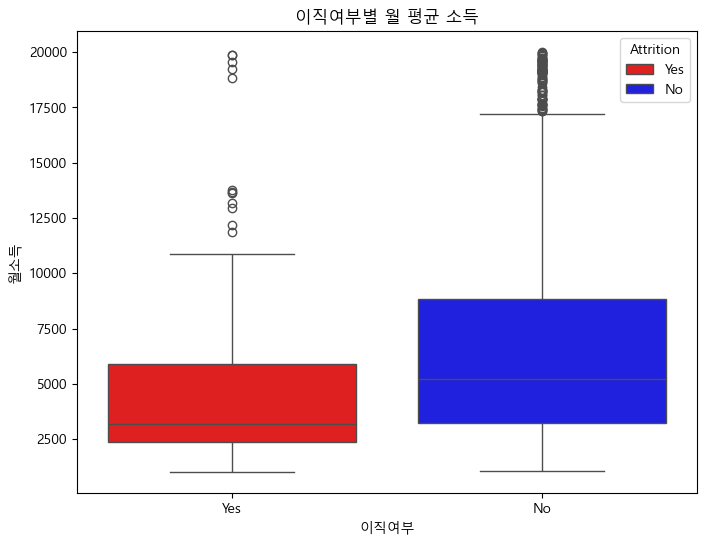

검증
----------------------------------------------------------
이직자의 월평균 소득은 약 $4787이고, 잔류자의 월평균 소득은 약$6832이다
이직자와 잔류자의 월평균 소득이 약 $2000정도 차이가 나는 것을 보아 월소득와 이직여부는 관계가 있다
가설은 참이다!
----------------------------------------------------------


In [173]:
monthlyincome_mean = df.groupby("Attrition")["MonthlyIncome"].agg("mean")
print(monthlyincome_mean, end="\n\n")

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", hue="Attrition", legend=True, palette=["r", "b"])
plt.title("이직여부별 월 평균 소득")
plt.xlabel("이직여부")
plt.ylabel("월소득")
plt.show()

print("검증")
print("----------------------------------------------------------")
print("이직자의 월평균 소득은 약 $4787이고, 잔류자의 월평균 소득은 약$6832이다")
print("이직자와 잔류자의 월평균 소득이 약 $2000정도 차이가 나는 것을 보아 월소득와 이직여부는 관계가 있다\n가설은 참이다!")
print("----------------------------------------------------------")

## 3. 마지막 승진 후 기간(YearsSinceLastPromotion)이 길어질수록 이직률이 높아진다는 가설이 맞는지 결과를 분석하고 그래프로 나타내고 서술하세요,
- 마지막 승진 후 기간별 이직률(%)을 집계하고, 변화 흐름을 파악하기 적합한 그래프를 생성하세요.

    YearsSinceLastPromotion   yes_rate     no_rate
0                         0  18.932874   81.067126
1                         1  13.725490   86.274510
2                         2  16.981132   83.018868
3                         3  17.307692   82.692308
4                         4   8.196721   91.803279
5                         5   4.444444   95.555556
6                         6  18.750000   81.250000
7                         7  21.052632   78.947368
8                         8   0.000000  100.000000
9                         9  23.529412   76.470588
10                       10  16.666667   83.333333
11                       11   8.333333   91.666667
12                       12   0.000000  100.000000
13                       13  20.000000   80.000000
14                       14  11.111111   88.888889
15                       15  23.076923   76.923077



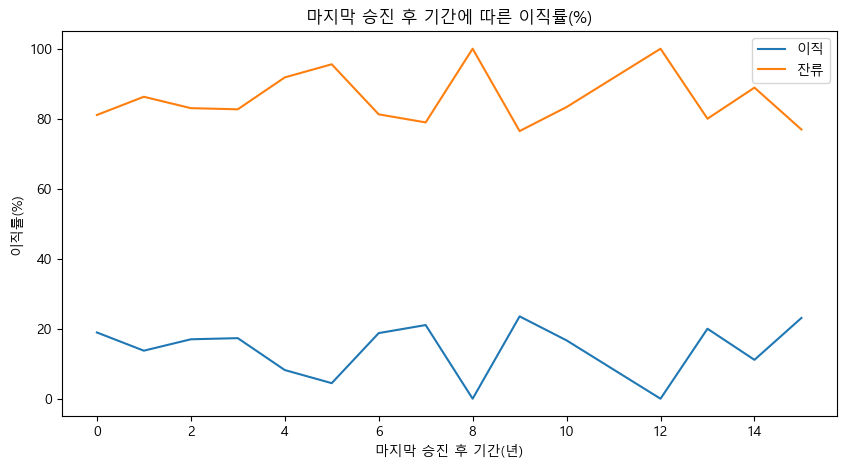

검증
----------------------------------------------------------
0~2년 동안 승진을 못했을 경우 평균 이직률이 약 16.5%가 나온다. 하지만 그 이후부터는 역전현상으로 이직률이 하락했다가
5년차부터 이직률이 다시 급등하는 것을 확인할 수 있다. 이와 비슷하게 7, 9년차에서도 똑같은 현상이 발생하는 것을 확인할 수 있다.
가설은 거짓이다!
----------------------------------------------------------


In [183]:
year_attririon_df = df.groupby("YearsSinceLastPromotion")["Attrition"].agg(
    yes_rate = (lambda x: (x=="Yes").mean()*100),
    no_rate = (lambda x: (x=="No").mean()*100)
).reset_index()
print(year_attririon_df, end="\n\n")

plt.figure(figsize=(10, 5))
plt.plot(year_attririon_df["YearsSinceLastPromotion"], year_attririon_df["yes_rate"], label="이직")
plt.plot(year_attririon_df["YearsSinceLastPromotion"], year_attririon_df["no_rate"], label="잔류")
plt.title("마지막 승진 후 기간에 따른 이직률(%)")
plt.xlabel("마지막 승진 후 기간(년)")
plt.ylabel("이직률(%)")
plt.legend()
plt.show()

print("검증")
print("----------------------------------------------------------")
print("0~2년 동안 승진을 못했을 경우 평균 이직률이 약 16.5%가 나온다. 하지만 그 이후부터는 역전현상으로 이직률이 하락했다가")
print("5년차부터 이직률이 다시 급등하는 것을 확인할 수 있다. 이와 비슷하게 7, 9년차에서도 똑같은 현상이 발생하는 것을 확인할 수 있다.")
print("가설은 거짓이다!")
print("----------------------------------------------------------")

## 4. 워라밸 만족도(WorkLifeBalance: 1~4점) 점수별 이직률을 구하고, 워라밸이 낮을 때(1점)의 이직 위험도를 분석하고 그래프로 나타내고 서술하세요,
- WorkLifeBalance 척도(1점: Bad ~ 4점: Best)별 이직률(%)을 구하고, 그룹 간 크기 비교에 적합한 그래프를 생성하세요.

   WorkLifeBalance  Attrition
0                1  31.250000
1                2  16.860465
2                3  14.221725
3                4  17.647059



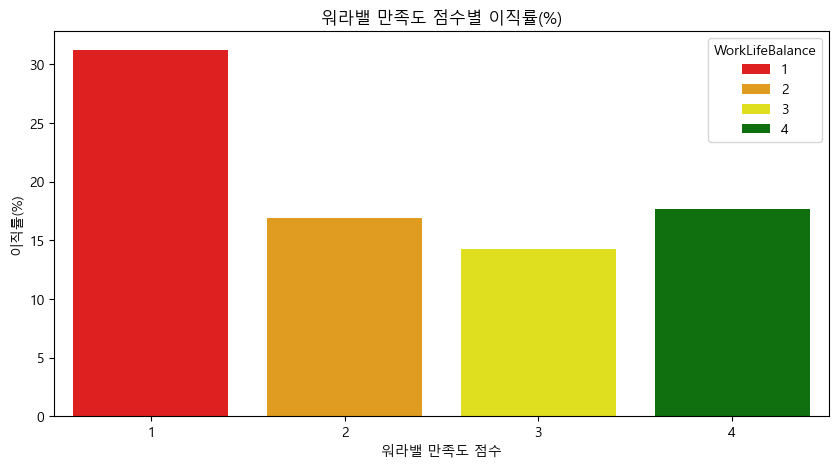

검증
----------------------------------------------------------
워라밸 만족도 1점의 이직률은 31.3%, 2~4점의 이직률은 16.2%로 워라밸 만족도 1점의 이직률이 15.1%가 높게 나오것을 보아
직장내 괴롭힘, 야근, 상사의 폭언 등의 이유로 이직하는 경우가 많다고 판단된다.
가설은 참이다
----------------------------------------------------------


In [176]:
worklifebalance_attrition_df = df.groupby("WorkLifeBalance")["Attrition"].apply(lambda x: (x=="Yes").mean() * 100).reset_index()
print(worklifebalance_attrition_df, end="\n\n")

plt.figure(figsize=(10, 5))
sns.barplot(data=worklifebalance_attrition_df, x="WorkLifeBalance", y="Attrition", hue="WorkLifeBalance", palette=["red", "orange", "yellow", "green"])
plt.title("워라밸 만족도 점수별 이직률(%)")
plt.xlabel("워라밸 만족도 점수")
plt.ylabel("이직률(%)")
plt.show()

print("검증")
print("----------------------------------------------------------")
print("워라밸 만족도 1점의 이직률은 31.3%, 2~4점의 이직률은 16.2%로 워라밸 만족도 1점의 이직률이 15.1%가 높게 나오것을 보아")
print("야근이 주요인이고 이는 과도한 업무량, 팀 업무능력 등의 이유로 이직하는 경우가 많다고 판단된다.\n가설은 참이다")
print("----------------------------------------------------------")